Step 1: Import Libraries

In [29]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder

# Model
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

Step 2: Load Train & Test Data

In [30]:
# Load datasets
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

In [31]:
# View Training data
print("Training Data: ",train.head())

Training Data:     employee_id         department     region         education gender  \
0        65438  Sales & Marketing   region_7  Master's & above      f   
1        65141         Operations  region_22        Bachelor's      m   
2         7513  Sales & Marketing  region_19        Bachelor's      m   
3         2542  Sales & Marketing  region_23        Bachelor's      m   
4        48945         Technology  region_26        Bachelor's      m   

  recruitment_channel  no_of_trainings  age  previous_year_rating  \
0            sourcing                1   35                   5.0   
1               other                1   30                   5.0   
2            sourcing                1   34                   3.0   
3               other                2   39                   1.0   
4               other                1   45                   3.0   

   length_of_service  KPIs_met >80%  awards_won?  avg_training_score  \
0                  8              1            0          

In [32]:
# View Test data
print("Test Data: ",test.head())

Test Data:     employee_id         department     region   education gender  \
0         8724         Technology  region_26  Bachelor's      m   
1        74430                 HR   region_4  Bachelor's      f   
2        72255  Sales & Marketing  region_13  Bachelor's      m   
3        38562        Procurement   region_2  Bachelor's      f   
4        64486            Finance  region_29  Bachelor's      m   

  recruitment_channel  no_of_trainings  age  previous_year_rating  \
0            sourcing                1   24                   NaN   
1               other                1   31                   3.0   
2               other                1   31                   1.0   
3               other                3   31                   2.0   
4            sourcing                1   30                   4.0   

   length_of_service  KPIs_met >80%  awards_won?  avg_training_score  
0                  1              1            0                  77  
1                  5        

Step 3: Exploratory Data Analysis (EDA)

In [33]:
# Check basic info
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [34]:
# Check basic info
train.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [35]:
# Check duplicate entries
train.duplicated().sum()

# This shows there are no duplicate entries in the training dataset

np.int64(0)

In [36]:
# Check missing values
train.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [40]:
# Check class imbalance
train['is_promoted'].value_counts(normalize=True)

,proportion
is_promoted,
0,0.91483
1,0.08517


Step 4: Pre-processing (Train Data)

In [46]:
# Fill missing values
train['education'].fillna(train['education'].mode()[0], inplace=True)
train['previous_year_rating'].fillna(train['previous_year_rating'].median(), inplace=True)

# Feature Engineering (simple but effective)
train['service_to_age'] = train['length_of_service'] / train['age']

/tmp/ipykernel_6502/972831268.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['education'].fillna(train['education'].mode()[0], inplace=True)
/tmp/ipykernel_6502/972831268.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [47]:
# Check again for missing values
train.isnull().sum()

# No more missing values in training dataset

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


In [48]:
# Encode categorical variables
le = LabelEncoder()

categorical_cols = ['department', 'region', 'education', 'gender', 'recruitment_channel']

for col in categorical_cols:
    train[col] = le.fit_transform(train[col])

Step 5: Data Visualization

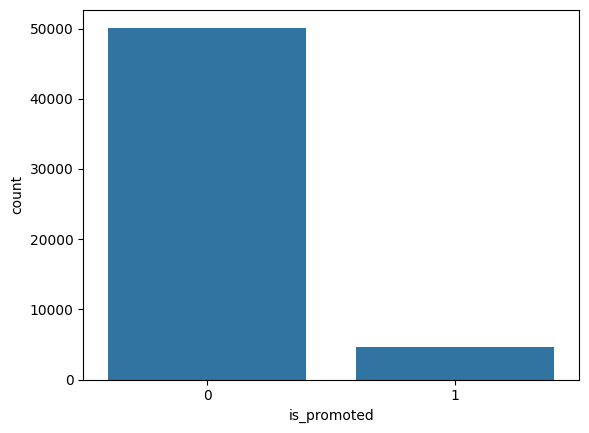

In [49]:
# Check target distribution
sns.countplot(x='is_promoted', data=train)
plt.show()

Step 6: Prepare Features & Target

In [50]:
# Drop employee_id
X = train.drop(['employee_id', 'is_promoted'], axis=1)
y = train['is_promoted']

Step 7: Train-Test Split (for evaluation)

In [51]:
# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

Step 8: Model (Handle Imbalance)

In [52]:
# Calculate imbalance ratio
scale_pos_weight = train['is_promoted'].value_counts()[0] / train['is_promoted'].value_counts()[1]

# Improved XGBoost model
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:47:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

Step 9: Evaluation (F1 Score + Threshold tuning)

In [53]:
# Predict probabilities
y_prob = model.predict_proba(X_val)[:,1]

# Fine tuning threshold
best_f1 = 0
best_threshold = 0

for t in np.arange(0.35, 0.51, 0.02):
    y_pred = (y_prob > t).astype(int)
    score = f1_score(y_val, y_pred)

    print("Threshold:", t, "F1 Score:", score)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Threshold: 0.35 F1 Score: 0.3725581395348837
Threshold: 0.37 F1 Score: 0.3780546238620029
Threshold: 0.39 F1 Score: 0.3847852760736196
Threshold: 0.41000000000000003 F1 Score: 0.3882412569690826
Threshold: 0.43000000000000005 F1 Score: 0.389338907760648
Threshold: 0.45000000000000007 F1 Score: 0.39384947396816833
Threshold: 0.4700000000000001 F1 Score: 0.39620535714285715
Threshold: 0.4900000000000001 F1 Score: 0.4009310445155659
Threshold: 0.5100000000000001 F1 Score: 0.40354090354090355
Best Threshold: 0.5100000000000001
Best F1 Score: 0.40354090354090355


Step 10: Pre-process Test Data

In [57]:
# Fill missing values
test['education'].fillna(test['education'].mode()[0], inplace=True)
test['previous_year_rating'].fillna(test['previous_year_rating'].median(), inplace=True)

# Encode categorical variables
for col in categorical_cols:
    test[col] = le.fit_transform(test[col])

# Add feature (same as train)
test['service_to_age'] = test['length_of_service'] / test['age']

/tmp/ipykernel_6502/2787631159.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['education'].fillna(test['education'].mode()[0], inplace=True)
/tmp/ipykernel_6502/2787631159.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

Step 11: Final Model Training on Full Data

In [58]:
final_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

final_model.fit(X, y)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:26:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

Step 12: Predict on Test Data

In [59]:
# Prepare test features
test_X = test.drop(['employee_id'], axis=1)

# Predict probabilities
test_prob = final_model.predict_proba(test_X)[:,1]

# Apply best threshold (from Step 9)
test['is_promoted'] = (test_prob > 0.51).astype(int)

Step 13: Create Submission File

In [61]:
# Load sample submission
submission = pd.read_csv("/content/sample_submission.csv")

# Replace target column
submission['is_promoted'] = test['is_promoted']

# Save CSV
submission.to_csv("final_submission.csv", index=False)